
<h1 align="center"> Statistics and Financial Data Analysis
<h1 align="center"> Examples


In [1]:
import pandas_datareader as pd_data
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import math
import scipy as sp
from statsmodels.distributions.empirical_distribution import ECDF
from statsmodels.stats.anova import anova_lm

In [2]:
start_date = '2018-01-01'
end_date = '2018-12-31'
GS = pd_data.DataReader('GS','yahoo',start_date,end_date)
SPY = pd_data.DataReader('SPY','yahoo',start_date,end_date)
DIA = pd_data.DataReader('DIA','yahoo',start_date,end_date)
WMT = pd_data.DataReader('WMT','yahoo',start_date,end_date)
EURUSD = pd_data.DataReader('EURUSD=X','yahoo',start_date,end_date)
GBPUSD = pd_data.DataReader('GBPUSD=X','yahoo',start_date,end_date)

AttributeError: 'NoneType' object has no attribute 'group'

In [4]:
GSrtn = np.log(GS['Adj Close']).diff().dropna()
SPYrtn = np.log(SPY['Adj Close']).diff().dropna()
DIArtn = np.log(DIA['Adj Close']).diff().dropna()
WMTrtn = np.log(WMT['Adj Close']).diff().dropna()
EURUSDrtn = np.log(EURUSD['Close']).diff().dropna()
GBPUSDrtn = np.log(GBPUSD['Close']).diff().dropna()

In [5]:
names = ['GS','SPY','DIA','WMT','EURUSD','GBPUSD']
fullList = [GSrtn,SPYrtn,DIArtn,WMTrtn,EURUSDrtn,GBPUSDrtn]
myDict = dict(zip(names, fullList))
df_2 = pd.DataFrame({ key:pd.Series(value) for key, value in myDict.items()})
df_equit = df_2.dropna()

In [6]:
names = ['SPY','DIA','WMT','EURUSD','GBPUSD']
fullList = [SPYrtn,DIArtn,WMTrtn,EURUSDrtn,GBPUSDrtn]
myDict = dict(zip(names, fullList))
df_3 = pd.DataFrame({ key:pd.Series(value) for key, value in myDict.items()})
df_equit3 = df_3.dropna()

In [7]:
names = ['GS','SPY','DIA']
fullList = [GSrtn,SPYrtn,DIArtn]
myDict = dict(zip(names, fullList))
df_4 = pd.DataFrame({ key:pd.Series(value) for key, value in myDict.items()})
df_equit4 = df_4.dropna()

In [31]:
df_equit4

,GS,SPY,DIA
Date,,,
2018-01-03,-0.009353,0.006305,0.003743
2018-01-04,0.013879,0.004206,0.006606
2018-01-05,-0.005114,0.006642,0.008424
2018-01-08,-0.014626,0.001826,-0.000515
2018-01-09,0.008423,0.002261,0.004858
...,...,...,...
2018-12-24,-0.023389,-0.026778,-0.027094
2018-12-26,0.041223,0.049290,0.047501
2018-12-27,0.015106,0.007648,0.011088


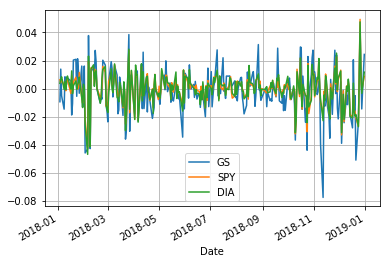

In [33]:
df_4.plot()
plt.grid()

In [8]:
SPYrtn.describe()

count    250.000000
mean      -0.000216
std        0.010771
min       -0.042722
25%       -0.004388
50%        0.000358
75%        0.005428
max        0.049290
Name: Adj Close, dtype: float64

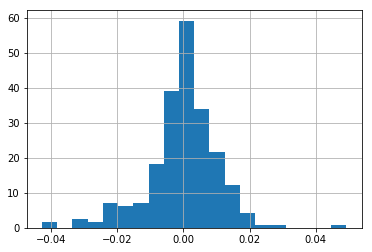

In [9]:
SPYrtn.hist(density = True, bins = 20)

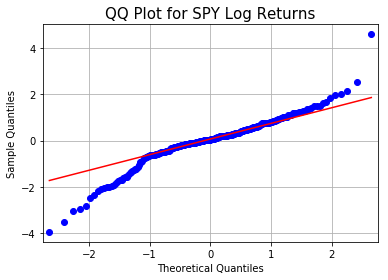

In [10]:
import statsmodels.api as sm
fig = sm.qqplot(SPYrtn, fit = True, line = 'q')
plt.title('QQ Plot for SPY Log Returns', fontsize=15)
plt.grid()
plt.show()

In [11]:
mean_annualised = SPYrtn.mean()*252*100
mean_annualised

-5.432973133166821

In [12]:
SPYrtn.mean()

-0.00021559417195106433

In [13]:
sp.stats.ttest_1samp(SPYrtn, 0 ) # H0 = avg return is equal to zero

Ttest_1sampResult(statistic=-0.3164726681107528, pvalue=0.7519089139418846)

In [14]:
sp.stats.ttest_1samp(SPYrtn, 0.01 ) # H0 = avg return is equal to 10

Ttest_1sampResult(statistic=-14.995564651292279, pvalue=1.1775183680033698e-36)

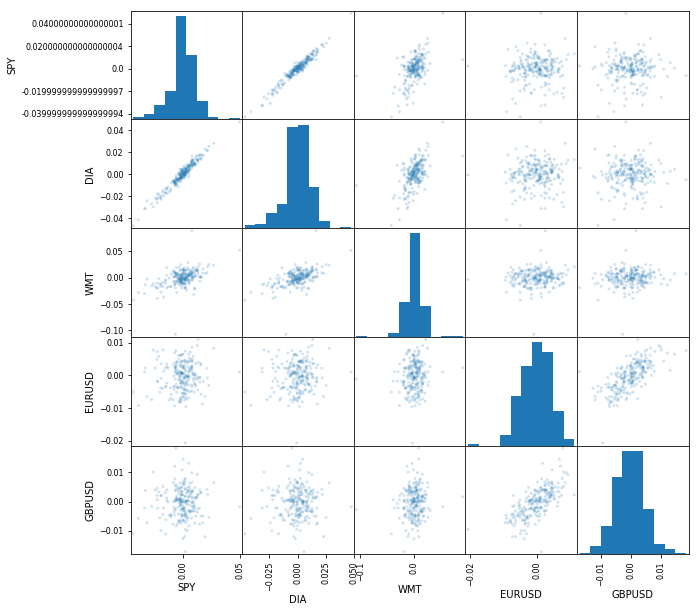

In [15]:
pd.plotting.scatter_matrix(df_equit3, alpha = 0.2, figsize= (10,10), );

In [17]:
# Regress GSrtn against all other rtn

X = df_equit3
y = df_equit['GS']

Xnew = sm.add_constant(X)
model5 = sm.OLS(y, Xnew).fit()
y_fitted = model5.predict(Xnew)
model5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     GS   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.633
Method:                 Least Squares   F-statistic:                     76.52
Date:                Thu, 14 Oct 2021   Prob (F-statistic):           9.99e-46
Time:                        06:48:48   Log-Likelihood:                 696.39
No. Observations:                 220   AIC:                            -1381.
Df Residuals:                     214   BIC:                            -1360.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0011      0.001     -1.521      0.130      -0.002       0.000
SPY            0.1335      0.282      0.473      0.637      -0.423       0.690
DIA            1.1038      0.276      4.001      0.000       0.560       1.648
WMT           -0.1160      0.053     -2.174      0.031      -0.221      -0.011
EURUSD        -0.0152      0.221     -0.069      0.945      -0.450       0.420
GBPUSD         0.3073      0.192      1.597      0.112      -0.072       0.687
==============================================================================
Omnibus:                       22.168   Durbin-Watson:                   1.970
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               66.321
Skew:                          -0.336   Prob(JB):                     3.97e-15
Kurtosis:                       5.605   Cond. No.                         561.
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
# Regress GSrtn against all other rtn

In [19]:
X = df_equit4['SPY']
y = df_equit4['GS']
Xnew = sm.add_constant(X)
model1 = sm.OLS(y, Xnew).fit()
y_fitted = model1.predict(Xnew)
#model1.summary()

In [20]:
model1.aic

-1570.3950415678785

In [21]:
X = df_equit4['DIA']
y = df_equit4['GS']
Xnew = sm.add_constant(X)
model2 = sm.OLS(y, Xnew).fit()
y_fitted = model2.predict(Xnew)
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     GS   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     397.0
Date:                Thu, 14 Oct 2021   Prob (F-statistic):           2.16e-53
Time:                        06:48:52   Log-Likelihood:                 794.58
No. Observations:                 250   AIC:                            -1585.
Df Residuals:                     248   BIC:                            -1578.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0015      0.001     -2.287      0.023      -0.003      -0.000
DIA            1.1260      0.057     19.925      0.000       1.015       1.237
==============================================================================
Omnibus:                       29.690   Durbin-Watson:                   2.025
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               97.864
Skew:                          -0.424   Prob(JB):                     5.61e-22
Kurtosis:                       5.946   Cond. No.                         88.3
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
X = df_equit4[['DIA','SPY']]
y = df_equit4['GS']
Xnew = sm.add_constant(X)
model3 = sm.OLS(y, Xnew).fit()
y_fitted = model3.predict(Xnew)
#model3.summary()

In [23]:
table1 = anova_lm(model1,model2)
print(table1)

   df_resid       ssr  df_diff   ss_diff    F  Pr(>F)
0     248.0  0.026944      0.0       NaN  NaN     NaN
1     248.0  0.025400     -0.0  0.001544 -inf     NaN


In [24]:
table2 = anova_lm(model1,model3)
print(table2)

   df_resid       ssr  df_diff   ss_diff          F   Pr(>F)
0     248.0  0.026944      0.0       NaN        NaN      NaN
1     247.0  0.025357      1.0  0.001587  15.455595  0.00011


In [25]:
table3 = anova_lm(model2,model3)
print(table3)

   df_resid       ssr  df_diff   ss_diff         F    Pr(>F)
0     248.0  0.025400      0.0       NaN       NaN       NaN
1     247.0  0.025357      1.0  0.000042  0.413463  0.520813


In [26]:
print('AIC')
print('Model 1', model1.aic)
print('Model 2', model2.aic)
print('Model 3', model3.aic)
print("")
print('BIC')
print('Model 1', model1.bic)
print('Model 2', model2.bic)
print('Model 3', model3.bic)
print("")
print('R^2')
print('Model 1', model1.rsquared)
print('Model 2', model2.rsquared)
print('Model 3', model3.rsquared)
print("")
print('R^2 Adj')
print('Model 1', model1.rsquared_adj)
print('Model 2', model2.rsquared_adj)
print('Model 3', model3.rsquared_adj)

AIC
Model 1 -1570.3950415678785
Model 2 -1585.1502988742657
Model 3 -1583.5684343107935

BIC
Model 1 -1563.352119732154
Model 2 -1578.1073770385412
Model 3 -1573.0040515572068

R^2
Model 1 0.592130464115042
Model 2 0.6155067132693515
Model 3 0.616149256852238

R^2 Adj
Model 1 0.5904858288896994
Model 2 0.6139563371131795
Model 3 0.6130411536688553


Text(0.5, 1.0, 'QQ Plot')

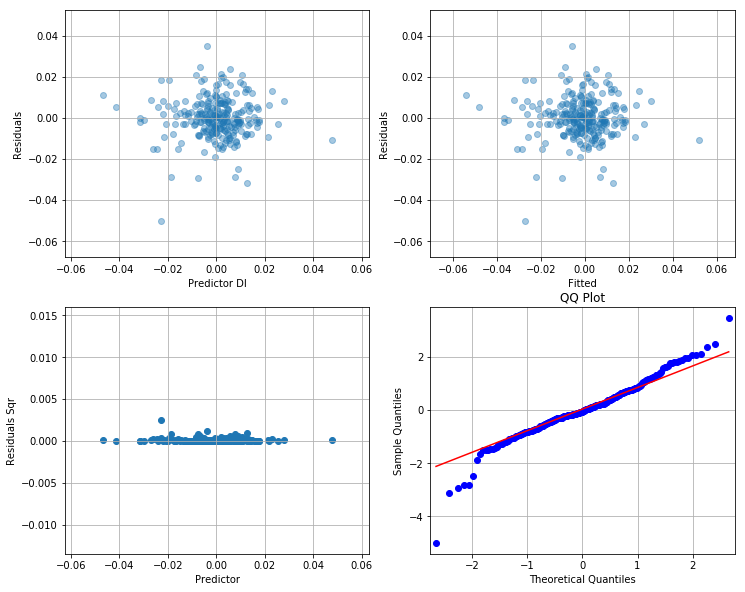

In [28]:
X = df_equit4['DIA']
y = df_equit4['GS']
Xnew = sm.add_constant(X)
model2 = sm.OLS(y, Xnew).fit()
y_fitted = model2.predict(Xnew)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,10))
ax= axes.flatten()

#fig.suptitle("A few diagnostic plots", size = 15)
res_2 = model2.resid
y_fitted = model2.predict(Xnew)


ax[0].scatter(df_equit4['DIA'], res_2, marker = 'o', alpha = 0.4)
ax[0].grid()
ax[0].set(xlabel = 'Predictor DI', ylabel = 'Residuals')

resSqr = model2.resid**2



ax[1].scatter(y_fitted, res_2, marker = 'o', alpha = 0.4)
ax[1].grid()  
ax[1].set(xlabel = 'Fitted', ylabel = 'Residuals')
1

ax[2].scatter(df_equit4['DIA'],resSqr )
ax[2].grid()
ax[2].set(xlabel = 'Predictor', ylabel = 'Residuals Sqr')


sm.qqplot(res_2, fit = True, line='q',ax = ax[3])
ax[3].grid()
ax[3].set_title("QQ Plot")


#plt.savefig("Diagnostics_graphs1")

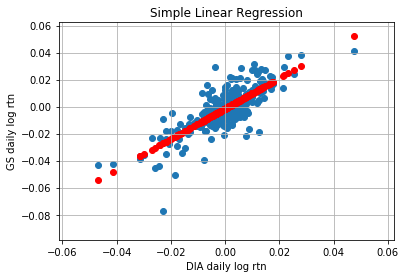

In [29]:
plt.scatter(df_equit4['DIA'],df_equit4['GS'])
plt.scatter(df_equit4['DIA'],y_fitted, color = 'red')
plt.title("Simple Linear Regression")
plt.ylabel("GS daily log rtn")
plt.xlabel("DIA daily log rtn")
plt.grid()
#plt.savefig("DIA_GS")

In [30]:
X = df_equit4['DIA']
y = df_equit4['SPY']
Xnew = sm.add_constant(X)
model5 = sm.OLS(y, Xnew).fit()
y_fitted = model5.predict(Xnew)
model5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    SPY   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     4481.
Date:                Thu, 14 Oct 2021   Prob (F-statistic):          8.95e-161
Time:                        06:49:14   Log-Likelihood:                 1147.0
No. Observations:                 250   AIC:                            -2290.
Df Residuals:                     248   BIC:                            -2283.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6.508e-05      0.000     -0.416      0.678      -0.000       0.000
DIA            0.9239      0.014     66.943      0.000       0.897       0.951
==============================================================================
Omnibus:                        2.713   Durbin-Watson:                   2.031
Prob(Omnibus):                  0.258   Jarque-Bera (JB):                2.361
Skew:                          -0.198   Prob(JB):                        0.307
Kurtosis:                       3.265   Cond. No.                         88.3
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""